| Column Name            | Description             |
| ---------------------- | ----------------------- |
| CustomerID             | Customer Unique ID      |
| Gender                 | Male/Female             |
| Age                    | Customer Age            |
| Annual Income (k$)     | Annual Income           |
| Spending Score (1-100) | Spending Behavior Score |


In [ ]:
=> For K-Means Clustering, the most common approach on this dataset is to cluster customers based on:

-Annual Income (k$)
-Spending Score (1-100)

=> This helps identify customer segments such as:

-High Income, High Spending
-High Income, Low Spending
-Low Income, High Spending
-Low Income, Low Spending
-Average Customers

# STEP 1 : Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

#Ignore warnings

import warnings
warnings.filterwarnings('ignore')

# Step 2: Load Dataset

In [6]:
df = pd.read_csv("K_ Mean__Mall_Customers.csv")

print("Dataset Shape :", df.shape)

df.head(5)

Dataset Shape : (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Step 3: Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# Step 4: Check Missing Values

In [8]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# Step 5: Statistical Summary

In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Step 6: Exploratory Data Analysis (EDA)

# Distribution of Age

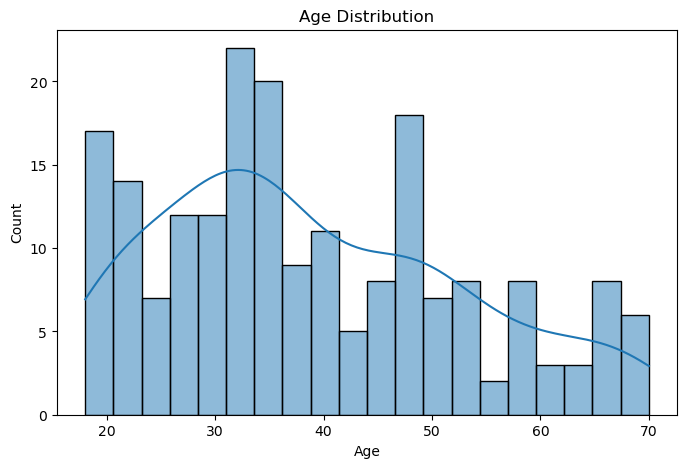

In [11]:
plt.figure(figsize = (8,5))

sns.histplot(
    df['Age'],
    bins = 20,
    kde = True
)

plt.title("Age Distribution")

plt.show()

# Annual Income Distribution

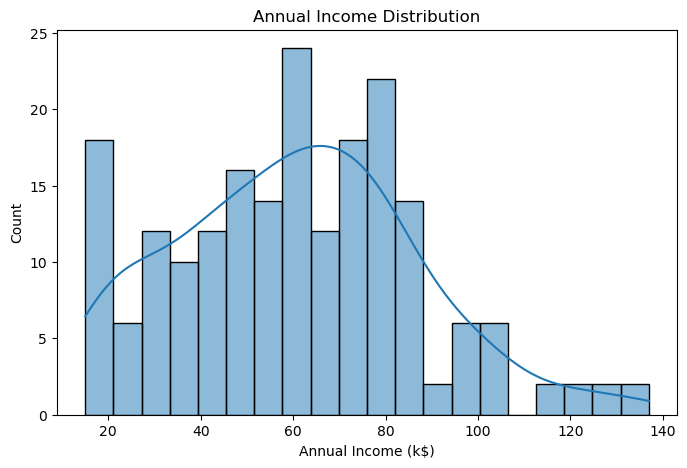

In [13]:
plt.figure(figsize = (8,5))

sns.histplot(
    df['Annual Income (k$)'],
    bins = 20,
    kde = True
)

plt.title("Annual Income Distribution")

plt.show()

# Spending Score Distribution

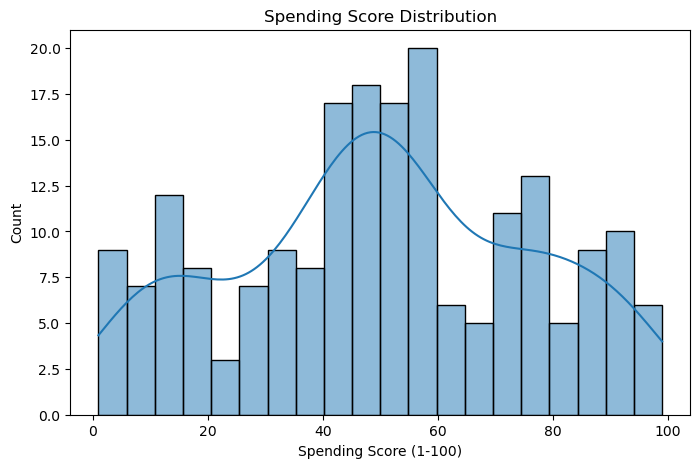

In [15]:
plt.figure(figsize = (8,5))

sns.histplot(
    df['Spending Score (1-100)'],
    bins = 20,
    kde = True
)

plt.title("Spending Score Distribution")

plt.show()

# Step 7: Scatter Plot Before Clustering

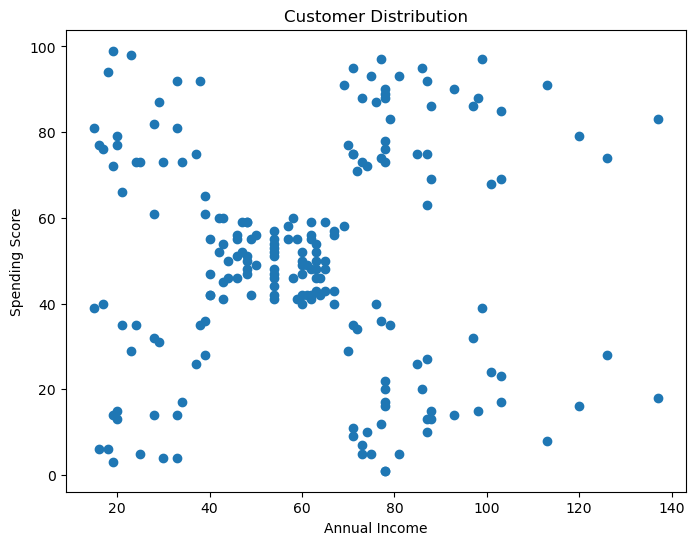

In [17]:
plt.figure(figsize = (8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)']
)

plt.title("Customer Distribution")

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.show()

# Step 8: Select Features for K-Means

In [18]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


# Step 9: Elbow Method

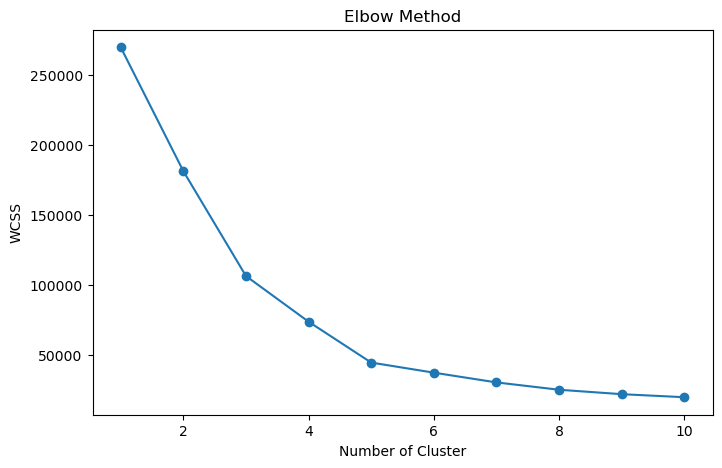

In [21]:
# WCSS (Within-Cluster Sum of Squares)

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters = i,
        init = 'k-means++',
        random_state = 42
    )
    
    kmeans.fit(X)
    
    wcss.append(kmeans.inertia_)
    
plt.figure(figsize = (8,5))

plt.plot(
    range(1,11),
    wcss,
    marker = 'o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Cluster")
plt.ylabel("WCSS")

plt.show()

In [22]:
n_clusters = 5

# Step 10: Train K-Means Model

In [23]:
kmeans = KMeans(
    n_clusters = 5,
    init = 'k-means++',
    random_state = 42
)

y_kmeans = kmeans.fit_predict(X)

print(y_kmeans)

[2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2
 3 2 3 2 3 2 0 2 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 4 1 4 0 4 1 4 1 4 0 4 1 4 1 4 1 4 1 4 0 4 1 4 1 4
 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1
 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4]


# Step 11: Add Cluster Labels

In [27]:
df['Cluster'] = y_kmeans

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,3
2,3,Female,20,16,6,2
3,4,Female,23,16,77,3
4,5,Female,31,17,40,2


# Step 12: Cluster Count

In [25]:
df['Cluster'].value_counts()

0    81
4    39
1    35
2    23
3    22
Name: Cluster, dtype: int64

# Step 13: Cluster Visualization

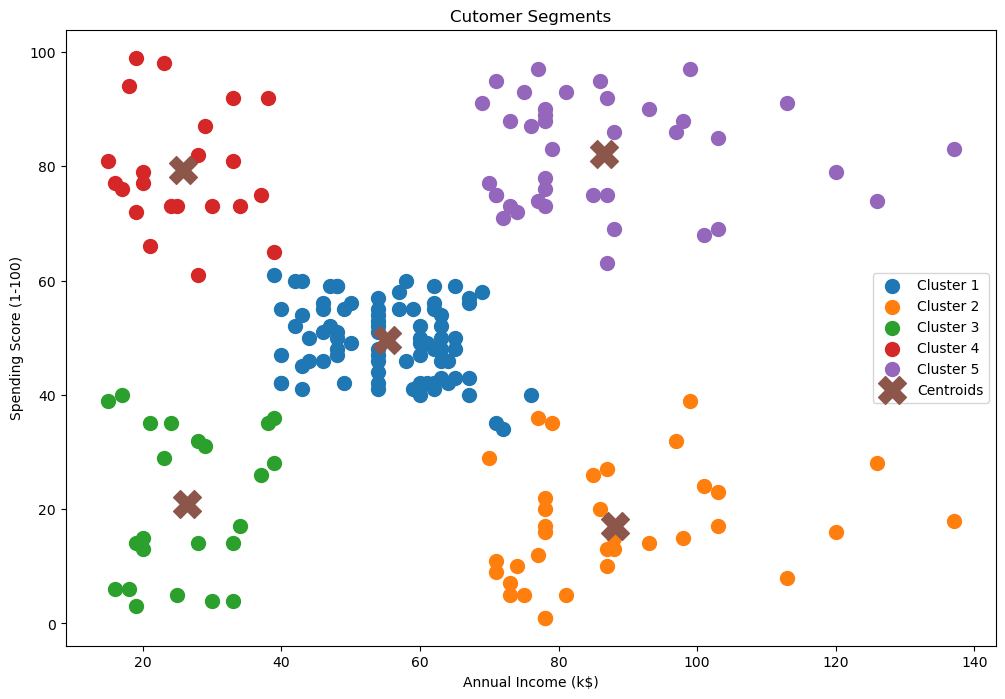

In [31]:
plt.figure(figsize = (12,8))

plt.scatter(
    X.iloc[y_kmeans == 0,0],
    X.iloc[y_kmeans == 0,1],
    s = 100,                 # The set of Cluster
    label = 'Cluster 1'
)

plt.scatter(
    X.iloc[y_kmeans == 1,0],
    X.iloc[y_kmeans == 1,1],
    s = 100,
    label = 'Cluster 2'
)

plt.scatter(
    X.iloc[y_kmeans == 2,0],
    X.iloc[y_kmeans == 2,1],
    s = 100,
    label = 'Cluster 3'
)

plt.scatter(
    X.iloc[y_kmeans == 3,0],
    X.iloc[y_kmeans == 3,1],
    s = 100,
    label = 'Cluster 4'
)

plt.scatter(
    X.iloc[y_kmeans == 4,0],
    X.iloc[y_kmeans == 4,1],
    s = 100,
    label = 'Cluster 5'
)


# Centroids

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s = 400,
    marker = 'X',
    label = 'Centroids'
)

plt.title("Cutomer Segments")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.legend()

plt.show()

# Step 14: Centroids

In [34]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns = [
        'Annual Income',
        'Spending Score'
    ]
)

centroids

,Annual Income,Spending Score
0,55.296296,49.518519
1,88.200000,17.114286
2,26.304348,20.913043
3,25.727273,79.363636
4,86.538462,82.128205


# Step 15: Cluster Analysis

In [36]:
cluster_analysis = df.groupby('Cluster').agg({
    
    'Age' : 'mean',
    'Annual Income (k$)' : 'mean',
    'Spending Score (1-100)' : 'mean'
    
}).round(2)

cluster_analysis

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.72,55.30,49.52
1,41.11,88.20,17.11
2,45.22,26.30,20.91
3,25.27,25.73,79.36
4,32.69,86.54,82.13


# Step 16: Cluster Analysis Graph

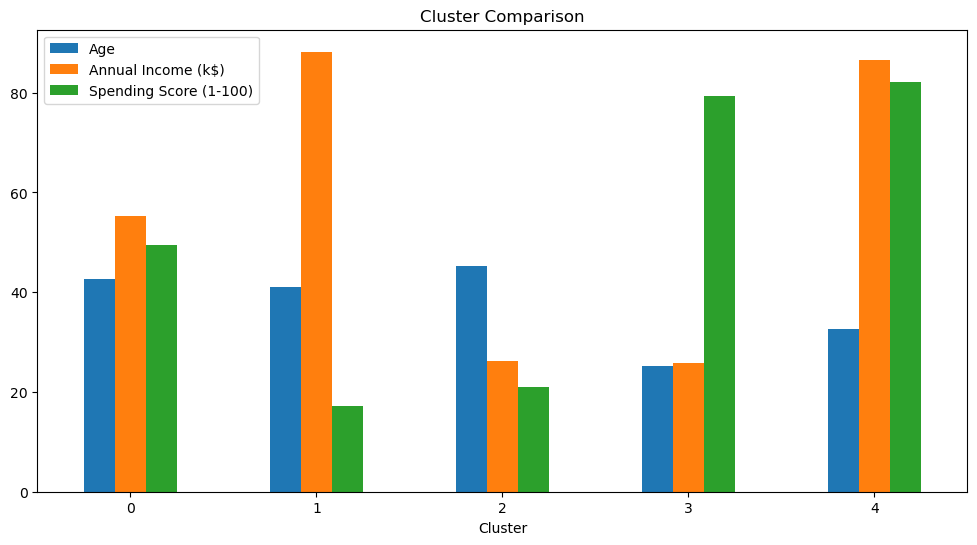

In [39]:
cluster_analysis.plot(
    kind = 'bar',
    figsize = (12,6)
)

plt.title("Cluster Comparison")

plt.xticks(rotation = 0)

plt.show()

# Step 17: Silhouette Score (Model Evaluation)

In [41]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, y_kmeans)

print("Silhouette Score :", round(score,3))

Silhouette Score : 0.554


# Step 18: Predict New Customer

In [42]:
new_customer = [[80,90]]

cluster = kmeans.predict(new_customer)

print("Predicted Cluster :", cluster[0])

Predicted Cluster : 4


# K-Means Workflow Summary